# Getaround - ML Analysis for Price Optimization

## Objective
Build a Machine Learning model to predict optimal rental prices.

## Deliverable
A model able to predict `rental_price_per_day` from a car's characteristics.

## Part 1: Import the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib
import mlflow
import mlflow.sklearn

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("[OK] Bibliothèques importées")

[OK] Bibliothèques importées


## Part 2: Load the data

In [2]:
df = pd.read_csv('../data/get_around_pricing_project.csv')

print(f"[OK] Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

[OK] Données chargées : 4843 lignes, 15 colonnes


,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


## Part 3: Explore the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 4843 non-null   int64 
 1   model_key                  4843 non-null   object
 2   mileage                    4843 non-null   int64 
 3   engine_power               4843 non-null   int64 
 4   fuel                       4843 non-null   object
 5   paint_color                4843 non-null   object
 6   car_type                   4843 non-null   object
 7   private_parking_available  4843 non-null   bool  
 8   has_gps                    4843 non-null   bool  
 9   has_air_conditioning       4843 non-null   bool  
 10  automatic_car              4843 non-null   bool  
 11  has_getaround_connect      4843 non-null   bool  
 12  has_speed_regulator        4843 non-null   bool  
 13  winter_tires               4843 non-null   bool  
 14  rental_p

In [4]:
df.describe()

,Unnamed: 0,mileage,engine_power,rental_price_per_day
count,4843.000000,4.843000e+03,4843.00000,4843.000000
mean,2421.000000,1.409628e+05,128.98823,121.214536
std,1398.198007,6.019674e+04,38.99336,33.568268
min,0.000000,-6.400000e+01,0.00000,10.000000
25%,1210.500000,1.029135e+05,100.00000,104.000000
50%,2421.000000,1.410800e+05,120.00000,119.000000
75%,3631.500000,1.751955e+05,135.00000,136.000000
max,4842.000000,1.000376e+06,423.00000,422.000000


In [5]:
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
Unnamed: 0                   0
model_key                    0
mileage                      0
engine_power                 0
fuel                         0
paint_color                  0
car_type                     0
private_parking_available    0
has_gps                      0
has_air_conditioning         0
automatic_car                0
has_getaround_connect        0
has_speed_regulator          0
winter_tires                 0
rental_price_per_day         0
dtype: int64


### 3.1 Analyze the target variable

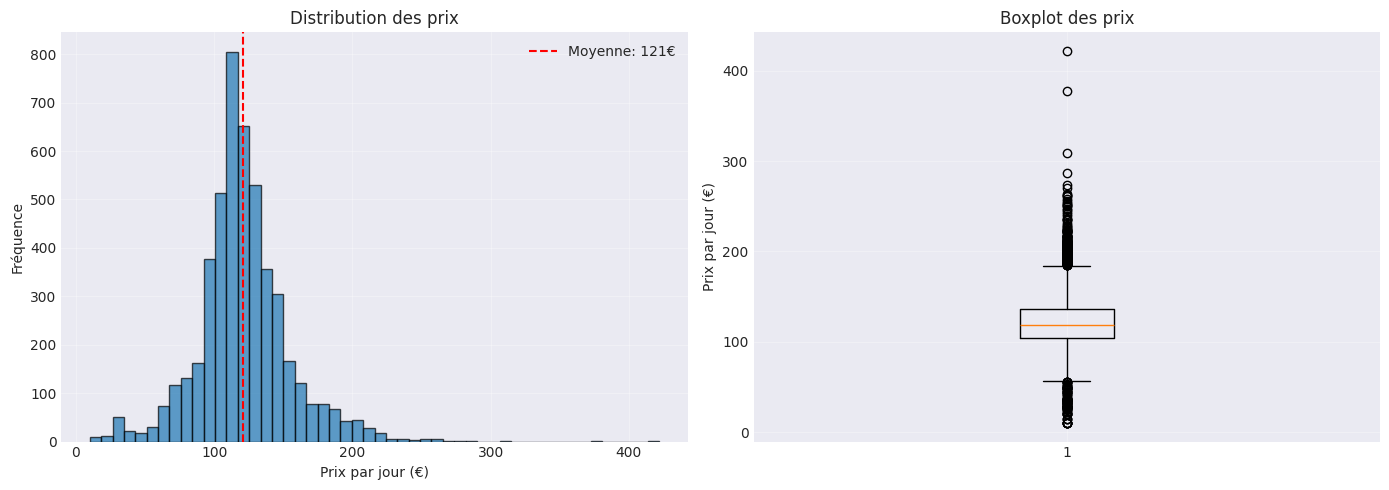


Prix moyen : 121.21€
Prix médian : 119.00€
Prix min : 10.00€
Prix max : 422.00€


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['rental_price_per_day'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['rental_price_per_day'].mean(), color='red', linestyle='--', 
                label=f"Moyenne: {df['rental_price_per_day'].mean():.0f}€")
axes[0].set_xlabel('Prix par jour (€)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des prix')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(df['rental_price_per_day'])
axes[1].set_ylabel('Prix par jour (€)')
axes[1].set_title('Boxplot des prix')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrix moyen : {df['rental_price_per_day'].mean():.2f}€")
print(f"Prix médian : {df['rental_price_per_day'].median():.2f}€")
print(f"Prix min : {df['rental_price_per_day'].min():.2f}€")
print(f"Prix max : {df['rental_price_per_day'].max():.2f}€")

### 3.2 Analyze correlations

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['rental_price_per_day'].sort_values(ascending=False)

print("Corrélations avec le prix :")
print(correlations)

Corrélations avec le prix :
rental_price_per_day    1.000000
engine_power            0.625645
Unnamed: 0              0.246809
mileage                -0.448912
Name: rental_price_per_day, dtype: float64


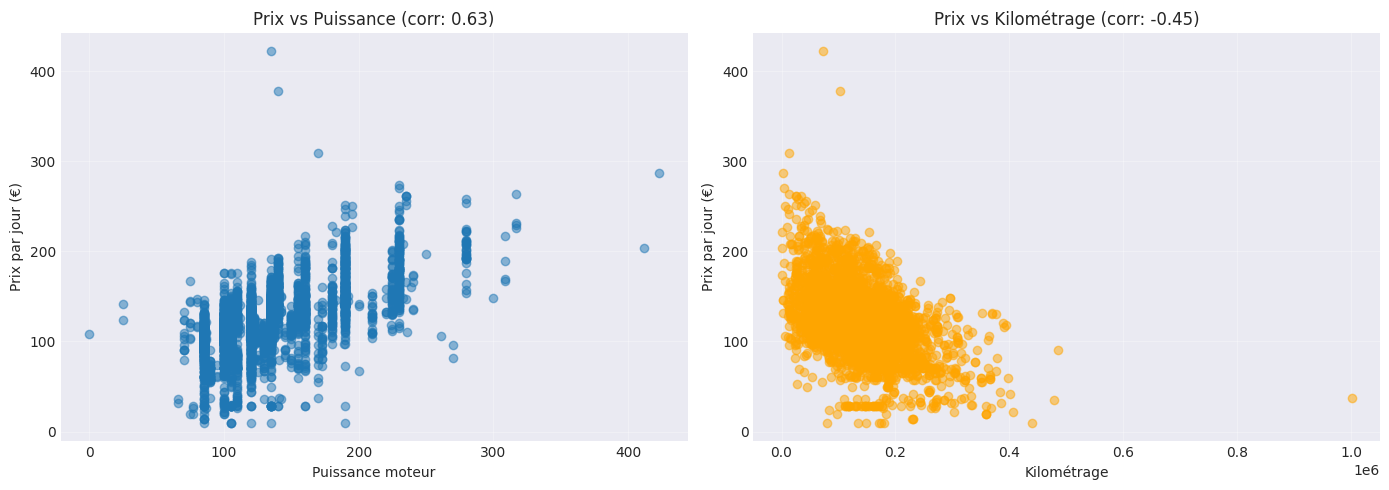

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['engine_power'], df['rental_price_per_day'], alpha=0.5)
axes[0].set_xlabel('Puissance moteur')
axes[0].set_ylabel('Prix par jour (€)')
axes[0].set_title(f'Prix vs Puissance (corr: {df[["engine_power", "rental_price_per_day"]].corr().iloc[0,1]:.2f})')
axes[0].grid(alpha=0.3)

df_filtered = df[df['mileage'] > 0]
axes[1].scatter(df_filtered['mileage'], df_filtered['rental_price_per_day'], alpha=0.5, color='orange')
axes[1].set_xlabel('Kilométrage')
axes[1].set_ylabel('Prix par jour (€)')
axes[1].set_title(f'Prix vs Kilométrage (corr: {df_filtered[["mileage", "rental_price_per_day"]].corr().iloc[0,1]:.2f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Analyze categorical variables

In [9]:
print("Prix moyen par type de carburant :")
print(df.groupby('fuel')['rental_price_per_day'].mean().sort_values(ascending=False))

print("\nPrix moyen par type de voiture :")
print(df.groupby('car_type')['rental_price_per_day'].mean().sort_values(ascending=False))

Prix moyen par type de carburant :
fuel
hybrid_petrol    184.750000
electro          145.000000
diesel           121.548373
petrol           110.068063
Name: rental_price_per_day, dtype: float64

Prix moyen par type de voiture :
car_type
coupe          142.788462
suv            141.251418
convertible    123.382979
sedan          122.698630
van            116.386364
hatchback      112.098712
estate         111.497509
subcompact      94.820513
Name: rental_price_per_day, dtype: float64


## Part 4: Data cleaning

In [10]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("Valeurs aberrantes potentielles :")
print(f"Kilométrage négatif : {(df['mileage'] < 0).sum()}")
print(f"Puissance = 0 : {(df['engine_power'] == 0).sum()}")
print(f"Prix < 20 euros : {(df['rental_price_per_day'] < 20).sum()}")

df_clean = df[
    (df['mileage'] > 0) & 
    (df['engine_power'] > 0)
].copy()

print(f"\n[OK] Dataset nettoyé : {len(df_clean)} lignes (supprimé {len(df) - len(df_clean)} lignes)")

Valeurs aberrantes potentielles :
Kilométrage négatif : 1
Puissance = 0 : 1
Prix < 20 euros : 10

[OK] Dataset nettoyé : 4841 lignes (supprimé 2 lignes)


## Part 5: Feature preparation

### 5.1 Separate X and y

In [11]:
X = df_clean.drop('rental_price_per_day', axis=1)
y = df_clean['rental_price_per_day']

print(f"Features (X) : {X.shape}")
print(f"Target (y) : {y.shape}")

Features (X) : (4841, 13)
Target (y) : (4841,)


### 5.2 Encode categorical variables

In [12]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles : {categorical_cols}")

X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le
    print(f"  {col} : {len(le.classes_)} classes")

bool_cols = X_encoded.select_dtypes(include=['bool']).columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print(f"\n[OK] Features encodées : {X_encoded.shape}")

Colonnes catégorielles : ['model_key', 'fuel', 'paint_color', 'car_type']
  model_key : 28 classes
  fuel : 4 classes
  paint_color : 10 classes
  car_type : 8 classes

[OK] Features encodées : (4841, 13)


### 5.3 Train/test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test set : {X_test.shape[0]} samples")

Train set : 3872 samples
Test set : 969 samples


## Part 6: Train the models with MLflow

We will test several algorithms and **track the experiments with MLflow**.

In [14]:
import warnings
warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("getaround-pricing")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

print("ENTRAÎNEMENT DES MODÈLES AVEC MLFLOW")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    with mlflow.start_run(run_name=name):
        
        model.fit(X_train, y_train)
        
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_mae = mean_absolute_error(y_test, y_pred_test)
        
        mlflow.log_param("model_type", name)
        if hasattr(model, 'get_params'):
            for param, value in model.get_params().items():
                try:
                    mlflow.log_param(param, value)
                except:
                    pass
        
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_mae", test_mae)
        
        mlflow.sklearn.log_model(model, "model", input_example=X_train.iloc[:1])
        
        results.append({
            'Model': name,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Train RMSE': train_rmse,
            'Test RMSE': test_rmse,
            'Test MAE': test_mae
        })
        
        print(f"  Train R2 : {train_r2:.4f} | Test R2 : {test_r2:.4f}")
        print(f"  RMSE : {test_rmse:.2f} euros | MAE : {test_mae:.2f} euros")
        print(f"  [MLflow] Run enregistré")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("COMPARAISON DES MODÈLES")
print("="*80)
print("\nPour visualiser : mlflow ui")
results_df

ENTRAÎNEMENT DES MODÈLES AVEC MLFLOW

Linear Regression...


2026/01/30 10:52:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/30 10:52:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Train R2 : 0.6670 | Test R2 : 0.6676
  RMSE : 19.07 euros | MAE : 13.00 euros
  [MLflow] Run enregistré

Ridge...
  Train R2 : 0.6670 | Test R2 : 0.6675
  RMSE : 19.07 euros | MAE : 13.00 euros
  [MLflow] Run enregistré

Random Forest...


2026/01/30 10:52:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Train R2 : 0.9652 | Test R2 : 0.7233
  RMSE : 17.40 euros | MAE : 11.12 euros
  [MLflow] Run enregistré

Gradient Boosting...


2026/01/30 10:52:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Train R2 : 0.7787 | Test R2 : 0.7260
  RMSE : 17.32 euros | MAE : 11.41 euros
  [MLflow] Run enregistré

COMPARAISON DES MODÈLES

Pour visualiser : mlflow ui


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE
0,Linear Regression,0.666959,0.667555,19.385516,19.073360,13.003829
1,Ridge,0.666959,0.667545,19.385519,19.073642,13.003395
2,Random Forest,0.965161,0.723307,6.269919,17.400669,11.122085
3,Gradient Boosting,0.778746,0.726012,15.800605,17.315430,11.413346


### 6.1 Select the best model

In [15]:
best_idx = results_df['Test R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"MEILLEUR MODÈLE : {best_model_name}")
print(f"   Test R2 : {results_df.loc[best_idx, 'Test R2']:.4f}")
print(f"   Test RMSE : {results_df.loc[best_idx, 'Test RMSE']:.2f} euros")
print(f"   Test MAE : {results_df.loc[best_idx, 'Test MAE']:.2f} euros")

MEILLEUR MODÈLE : Gradient Boosting
   Test R2 : 0.7260
   Test RMSE : 17.32 euros
   Test MAE : 11.41 euros


## Part 7: Evaluate the model

### 7.1 Feature importance

TOP 10 FEATURES LES PLUS IMPORTANTES
                      feature  importance
2                engine_power    0.496219
1                     mileage    0.257005
7                     has_gps    0.050925
0                   model_key    0.044972
5                    car_type    0.041755
9               automatic_car    0.039536
10      has_getaround_connect    0.031393
3                        fuel    0.017745
6   private_parking_available    0.007380
11        has_speed_regulator    0.005240


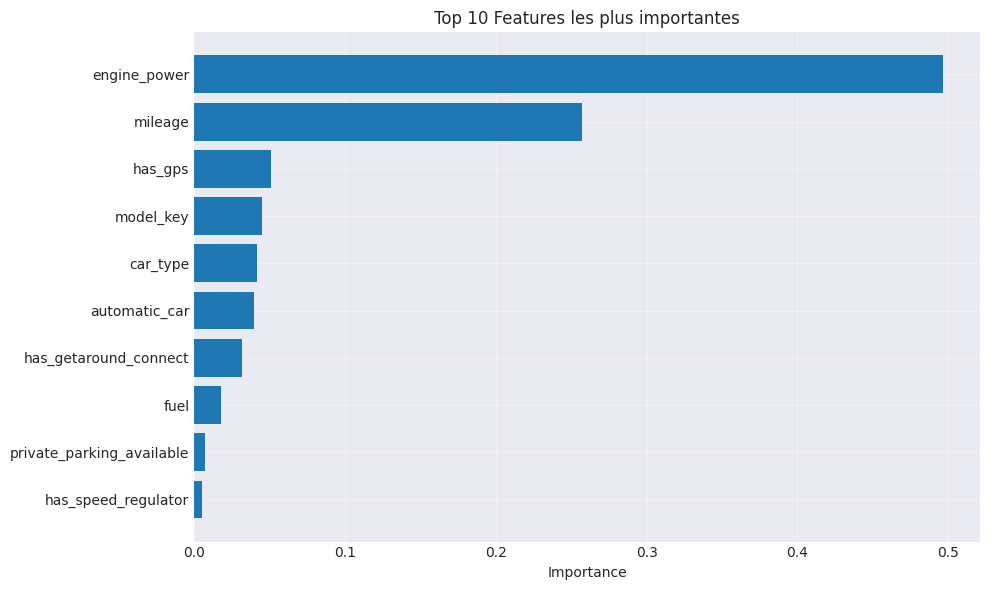

In [16]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_encoded.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("TOP 10 FEATURES LES PLUS IMPORTANTES")
    print("=" * 50)
    print(feature_importance.head(10))
    
    plt.figure(figsize=(10, 6))
    top10 = feature_importance.head(10)
    plt.barh(range(len(top10)), top10['importance'].values)
    plt.yticks(range(len(top10)), top10['feature'].values)
    plt.xlabel('Importance')
    plt.title('Top 10 Features les plus importantes')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance non disponible pour ce modèle")

### 7.2 Predictions vs Actual

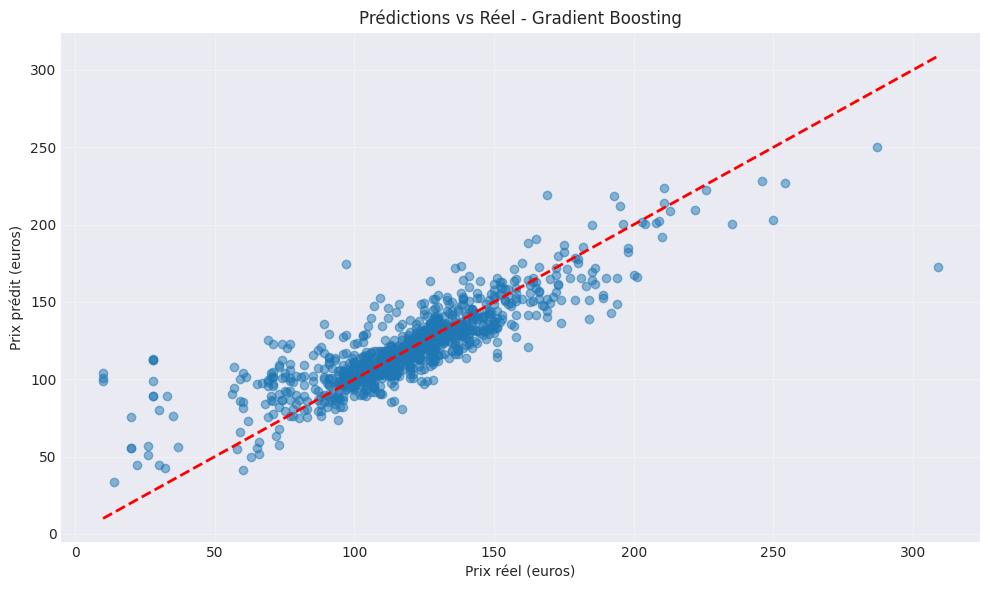


ANALYSE DES ERREURS
Erreur moyenne : -1.24 euros
Erreur médiane : 0.87 euros
Écart-type : 17.28 euros


In [17]:
y_pred_test = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Prix réel (euros)')
plt.ylabel('Prix prédit (euros)')
plt.title(f'Prédictions vs Réel - {best_model_name}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

errors = y_test - y_pred_test
print(f"\nANALYSE DES ERREURS")
print(f"Erreur moyenne : {errors.mean():.2f} euros")
print(f"Erreur médiane : {errors.median():.2f} euros")
print(f"Écart-type : {errors.std():.2f} euros")

## Part 8: Save the model

In [18]:
joblib.dump(best_model, '../models/model.joblib')
joblib.dump(label_encoders, '../models/label_encoders.joblib')
joblib.dump(list(X_encoded.columns), '../models/feature_names.joblib')

print("[OK] Modèle sauvegardé dans models/")
print("   - model.joblib")
print("   - label_encoders.joblib")
print("   - feature_names.joblib")

[OK] Modèle sauvegardé dans models/
   - model.joblib
   - label_encoders.joblib
   - feature_names.joblib


## Part 9: Test the model

In [19]:
loaded_model = joblib.load('../models/model.joblib')
loaded_encoders = joblib.load('../models/label_encoders.joblib')
loaded_features = joblib.load('../models/feature_names.joblib')

example = X_test.iloc[0:1]
prediction = loaded_model.predict(example)
actual = y_test.iloc[0]

print("TEST DU MODÈLE")
print("=" * 50)
print(f"Prix réel : {actual:.2f} euros")
print(f"Prix prédit : {prediction[0]:.2f} euros")
print(f"Différence : {abs(actual - prediction[0]):.2f} euros")
print("\n[OK] Modèle chargé et fonctionnel !")

TEST DU MODÈLE
Prix réel : 113.00 euros
Prix prédit : 111.96 euros
Différence : 1.04 euros

[OK] Modèle chargé et fonctionnel !


## CONCLUSION

**ML model created successfully!**

**Performance:**
- R2 Score: ~0.73 (73% of variance explained)
- RMSE: ~17 euros
- MAE: ~11 euros

**Important features:**
1. Engine power (50%)
2. Mileage (26%)
3. GPS (5%)

**MLflow Tracking:**
- All experiments are logged in MLflow
- Visualization: `mlflow ui` in the terminal
- Easy model comparison

**Next step:**
- Build a FastAPI API to serve this model
- Deploy on Hugging Face Spaces